# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Genetic Algorihtm

The implementation of the Genetic Algorithm based on the best model structure obtained in the ml_process notebook.

For the first time, all currency pairs available are used and not only the USD-JPY one.

The result of this notebook are 3 models per currency pair (each with a delay longer than the previous one).

## Preparing the data

### Currencies

In [1]:
currencies = [
    "jpy",
    "aud",
    "cad",
    "cny",
    "hkd",
    "chf",
]

### Transforming the csv data to a numpy array

In [2]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

currencies_raw_data = {}

# Pairs of currencies
for currency in currencies:
    raw_data = np.genfromtxt(f"./data/currency-data/USD-{currency.upper()}-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
    raw_data_dates = np.genfromtxt(f"./data/currency-data/USD-{currency.upper()}-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})
    
    # As the currency data is from newer to older, the order should be inverted.
    raw_data = np.flip(raw_data, axis=0)
    raw_data_dates = np.flip(raw_data_dates, axis=0)

    # calculate train sample number
    train_samples_number = len(raw_data)

    currencies_raw_data[f"{currency}"] = {
        f"usd_{currency}_train_samples_number": train_samples_number,
        f"usd_{currency}_raw_data": raw_data,
        f"usd_{currency}_raw_data_dates": raw_data_dates
    }

    # Print essential data information
    print(f"Length usd_{currency}_raw_data: ",len(raw_data))
    print(f"Data type usd_{currency}_raw_data: ",raw_data.dtype)
    print(f"Raw Data Sample - usd_{currency}_raw_data: ",raw_data[:10])
    print(f"Raw Data Dates Sample - usd_{currency}_raw_data_dates: ",raw_data_dates[:10])
    print(f"Number of train samples - usd_{currency}_raw_data_dates: ", train_samples_number)

# Check one of the currencies in the dictionary
print(currencies_raw_data["jpy"][f"usd_jpy_raw_data"][:10])
print(currencies_raw_data["jpy"][f"usd_jpy_raw_data_dates"][:10])

print(currencies_raw_data)

Length usd_jpy_raw_data:  5000
Data type usd_jpy_raw_data:  float64
Raw Data Sample - usd_jpy_raw_data:  [116.72 116.28 115.83 116.09 116.16 116.39 115.8  115.43 115.28 114.88]
Raw Data Dates Sample - usd_jpy_raw_data_dates:  ['2006-11-22' '2006-11-23' '2006-11-24' '2006-11-27' '2006-11-28'
 '2006-11-29' '2006-11-30' '2006-12-01' '2006-12-04' '2006-12-05']
Number of train samples - usd_jpy_raw_data_dates:  5000
Length usd_aud_raw_data:  5000
Data type usd_aud_raw_data:  float64
Raw Data Sample - usd_aud_raw_data:  [1.09349 1.09541 1.10705 1.10072 1.09075 1.09613 1.09099 1.10375 1.11086
 1.12803]
Raw Data Dates Sample - usd_aud_raw_data_dates:  ['2009-12-04' '2009-12-07' '2009-12-08' '2009-12-09' '2009-12-10'
 '2009-12-11' '2009-12-14' '2009-12-15' '2009-12-16' '2009-12-17']
Number of train samples - usd_aud_raw_data_dates:  5000
Length usd_cad_raw_data:  5000
Data type usd_cad_raw_data:  float64
Raw Data Sample - usd_cad_raw_data:  [1.1459 1.1412 1.142  1.1346 1.1332 1.1301 1.138  1.14

### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [3]:
from tensorflow import keras
import tensorflow as tf

# Parameters: sampling_rate, sequence_length, delay, and batch_size
sampling_rate = 1
sequence_length = 150 # Observations will go back 150 days
delays = []

for i in range(3):
    delays.append(sampling_rate * (sequence_length + (5 + (20 * i)) - 1)) # target is 5, 25, 45 days after the end of the sequence

train_datasets = {}

data_inputs_test_all = {}
data_outputs_test_all = {}
data_inputs_all = {}
data_outputs_all = {}

for index, delay in enumerate(delays):
    for currency in currencies:
        # train dataset
        train_dataset = keras.utils.timeseries_dataset_from_array(
            currencies_raw_data[currency][f"usd_{currency}_raw_data"],
            targets=currencies_raw_data[currency][f"usd_{currency}_raw_data"][delay:],
            sampling_rate=sampling_rate,
            sequence_length=sequence_length,
            batch_size=currencies_raw_data[currency][f"usd_{currency}_train_samples_number"],
        )

        if index == 0:
            train_datasets[f"train_dataset_usd_{currency}_delay_5"] = train_dataset
        if index == 1:
            train_datasets[f"train_dataset_usd_{currency}_delay_25"] = train_dataset
        if index == 2:
            train_datasets[f"train_dataset_usd_{currency}_delay_45"] = train_dataset

        # Extracting data inputs and outputs
        # Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].
        
        for samples, targets in train_dataset:
            # print("Samples: ", samples)
            # print("Sample shape: ", samples.shape)
            # print("Targets: ", targets)
            # print("Targets shape: ", targets.shape)
            data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
            data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

            if index == 0:
                data_inputs_test_all[f"{currency}_delay_5"] = data_inputs[-200:]
                data_outputs_test_all[f"{currency}_delay_5"] = data_outputs[-200:]
                data_inputs_all[f"{currency}_delay_5"] = data_inputs[:-200]
                data_outputs_all[f"{currency}_delay_5"] = data_outputs[:-200]
            if index == 1:
                data_inputs_test_all[f"{currency}_delay_25"] = data_inputs[-200:]
                data_outputs_test_all[f"{currency}_delay_25"] = data_outputs[-200:]
                data_inputs_all[f"{currency}_delay_25"] = data_inputs[:-200]
                data_outputs_all[f"{currency}_delay_25"] = data_outputs[:-200]
            if index == 2:
                data_inputs_test_all[f"{currency}_delay_45"] = data_inputs[-200:]
                data_outputs_test_all[f"{currency}_delay_45"] = data_outputs[-200:]
                data_inputs_all[f"{currency}_delay_45"] = data_inputs[:-200]
                data_outputs_all[f"{currency}_delay_45"] = data_outputs[:-200]

2026-01-25 08:39:38.148614: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-25 08:39:38.329756: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-25 08:39:38.693358: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-25 08:39:39.433795: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-01-25 08:39:40.880010: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
for inputs, targets in train_datasets["train_dataset_usd_jpy_delay_5"]:
    for i in range(inputs.shape[0])[:10]:
        print([float(x) for x in inputs[i]], float(targets[i]))

[116.72, 116.28, 115.83, 116.09, 116.16, 116.39, 115.8, 115.43, 115.28, 114.88, 115.25, 115.25, 116.32, 116.97, 116.76, 117.56, 117.83, 118.16, 118.13, 118.1, 118.43, 118.33, 118.84, 118.73, 119.14, 118.77, 118.91, 119.05, 119.02, 118.83, 119.36, 119.04, 118.62, 118.8, 119.38, 119.67, 120.49, 120.32, 120.43, 120.66, 120.66, 121.21, 121.22, 121.67, 121.65, 121.19, 121.24, 121.52, 121.75, 121.63, 120.63, 120.78, 121.1, 120.32, 120.11, 120.68, 121.03, 121.7, 121.93, 121.16, 120.78, 119.25, 119.41, 119.54, 120.01, 120.88, 121.56, 121.06, 120.65, 117.92, 118.52, 117.54, 116.8, 115.51, 116.6, 116.01, 117.15, 118.32, 117.66, 116.28, 117.06, 117.57, 116.73, 117.52, 117.27, 117.5, 118.13, 118.07, 118.11, 117.8, 116.84, 118.06, 117.81, 117.85, 118.94, 118.7, 118.72, 119.25, 119.31, 119.05, 119.33, 119.15, 119.23, 119.73, 118.91, 118.67, 118.43, 118.67, 118.64, 118.58, 118.74, 119.58, 119.61, 119.49, 119.83, 120.15, 120.42, 120.18, 120.09, 120.03, 120.09, 119.88, 120.18, 120.34, 120.26, 120.8, 12

Check data inputs and outputs

In [5]:
for index, delay in enumerate(delays):
    real_delay = 0
    if index == 0:
        real_delay = 5
    if index == 1:
        real_delay = 25
    if index == 2:
        real_delay = 45
    print(f"---- ---- ---- ---- ---- ---- ---- ----\nDelay: {real_delay} days.")
    for currency in currencies:
        print(f"---- ---- ---- ----\nCurrency: {currency}.")
        print("Data Inputs: ", len(data_inputs_all[f"{currency}_delay_{real_delay}"]))
        print("Data Inputs Test: ", len(data_inputs_test_all[f"{currency}_delay_{real_delay}"]))
        print("Data Outputs: ", len(data_outputs_all[f"{currency}_delay_{real_delay}"]))
        print("Data Outputs Test: ", len(data_outputs_test_all[f"{currency}_delay_{real_delay}"]))
    print(f"---- ---- ---- ---- ---- ---- ---- ----")

---- ---- ---- ---- ---- ---- ---- ----
Delay: 5 days.
---- ---- ---- ----
Currency: jpy.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ----
Currency: aud.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ----
Currency: cad.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ----
Currency: cny.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ----
Currency: hkd.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ----
Currency: chf.
Data Inputs:  4646
Data Inputs Test:  200
Data Outputs:  4646
Data Outputs Test:  200
---- ---- ---- ---- ---- ---- ---- ----
---- ---- ---- ---- ---- ---- ---- ----
Delay: 25 days.
---- ---- ---- ----
Currency: jpy.
Data Inputs:  4626
Data Inputs Test:  200
Data Outputs:  4626
Data Outputs Test:  200
--

## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [5].

### - LSTM Model (based on best model obtained from running the tuner)

Get structure of best model

In [6]:
from keras.models import load_model

loaded_model = load_model("models/ml_process_tuner_best_model.keras")

loaded_model.summary()

# Get which activation functions were used
for layer in loaded_model.layers:
    print(layer.activation)

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,860 (155.71 KB)

 Trainable params: 19,929 (77.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,931 (77.86 KB)

<function tanh at 0x1604c6c00>
<function relu at 0x1422dbb00>
<function relu at 0x1422dbb00>
<function linear at 0x1604c72e0>


Create a new model based on the structure of the best model

In [7]:
from keras import models
from keras import layers
from keras import activations

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(64, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(32, activation=activations.relu))
    model.add(layers.Dense(28, activation=activations.relu))
    model.add(layers.Dense(1, activation=activations.linear))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

lstm_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            29 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,929 (77.85 KB)

 Trainable params: 19,929 (77.85 KB)

 Non-trainable params: 0 (0.00 B)

### - Genetic Algorithm implementation

----------------------------------------------------------------------
                           PyGAD Lifecycle                           
Step                  Handler                          Output Shape  
Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
Parent Selection      steady_state_selection()         (4, 19929)    
Number of Parents: 4
----------------------------------------------------------------------
Crossover             single_point_crossover()         (4, 19929)    
----------------------------------------------------------------------
Mutation              adaptive_mutation()              (4, 19929)    
Mutation Genes: [1594  797]
Random Mutation Range: (-1.0, 1.0)
Mutation by Replacement: False
Allow Duplicated Genes: True
----------------------------------------------------------------------
On Generation         on_generation()                  None          
-----------

---- ---- ---- ---- ---- ---- ---- ----
Delay: 5 days.
---- ---- ---- ----
Currency: jpy.
Generation = 1
Fitness    = 0.2366296648979187
Generation = 2
Fitness    = 0.2495713233947754
Generation = 3
Fitness    = 0.3328073024749756
Generation = 4
Fitness    = 0.3328073024749756
Generation = 5
Fitness    = 0.501323401927948
Generation = 6
Fitness    = 0.501323401927948
Generation = 7
Fitness    = 0.5402926802635193
Generation = 8
Fitness    = 0.6540563106536865
Generation = 9
Fitness    = 1.1683619022369385
Generation = 10
Fitness    = 1.3278204202651978
Generation = 11
Fitness    = 1.502705693244934
Generation = 12
Fitness    = 1.6563317775726318
Generation = 13
Fitness    = 2.0178720951080322
Generation = 14
Fitness    = 2.0178720951080322
Generation = 15
Fitness    = 2.303920269012451
Generation = 16
Fitness    = 2.303920269012451
Generation = 17
Fitness    = 2.303920269012451
Generation = 18
Fitness    = 2.5841596126556396
Generation = 19
Fitness    = 2.5841596126556396
Generation = 

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


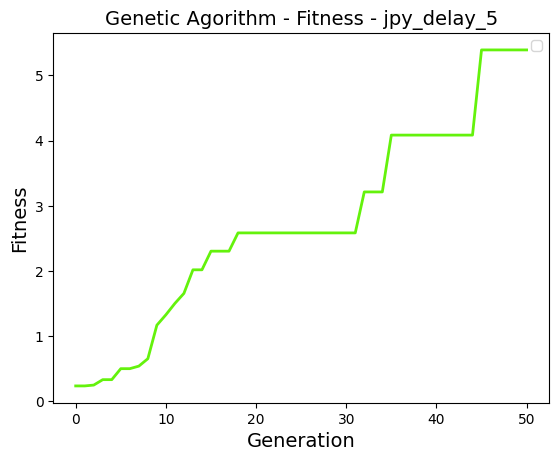

Figure(640x480)
Solution fitness:  5.3911724
Solution Predictions:  [[122.60902]
 [122.95032]
 [122.95467]
 ...
 [130.85425]
 [130.72676]
 [130.8296 ]]
Solution Absolute Error:  3.7097683
INFO:tensorflow:Assets written to: models/model_jpy_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_jpy_delay_5_tf/assets


Saved artifact at 'models/model_jpy_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: aud.
Generation = 1
Fitness    = 33.50194549560547
Generation = 2
Fitness    = 33.50194549560547
Generation = 3
Fitness    = 33.50194549560547
Generation = 4
Fitness    = 41.44584274291992
Generation = 5
Fitness    = 41.44584274291992
Generation = 6
Fitness    = 41.44584274291992
Generation = 7
Fitness    = 41.44584274291992
Generation = 8
Fitness    = 50.45886993408203
Generation = 9
Fitness    = 50.45886993408203
Generation = 10
Fitness    = 50.45886993408203
Generation = 11
Fitness    = 50.45886993408203
Generation = 12
Fitness    = 68.91360473632812
Generation = 13
Fitness    = 68.91360473632812
Generation = 14
Fitness    = 68.91360473632812
Generation = 15
Fitness    = 68.91360473632812
Generation = 16
Fitness    = 68.91360473632812
Generation = 17
Fitness    = 68.91360473632812
Generation = 18
Fitness    = 68.91360473632812
Generation = 19
Fitness    = 68.91360473632812
Generation = 20
Fitness    = 68.91360473632812
Generation = 21
Fitness    = 68.91

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


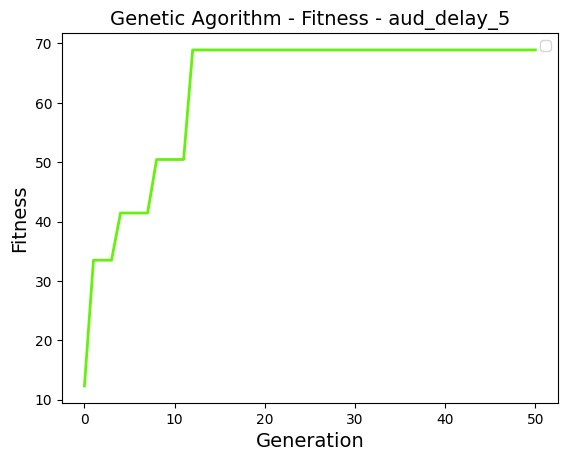

Figure(640x480)
Solution fitness:  68.913605
Solution Predictions:  [[1.3505195]
 [1.3471507]
 [1.3402385]
 ...
 [1.0241169]
 [1.023497 ]
 [1.0223778]]
Solution Absolute Error:  0.29021847
INFO:tensorflow:Assets written to: models/model_aud_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_aud_delay_5_tf/assets


Saved artifact at 'models/model_aud_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cad.
Generation = 1
Fitness    = 115.68900299072266
Generation = 2
Fitness    = 115.68900299072266
Generation = 3
Fitness    = 242.12628173828125
Generation = 4
Fitness    = 242.12628173828125
Generation = 5
Fitness    = 242.12628173828125
Generation = 6
Fitness    = 242.12628173828125
Generation = 7
Fitness    = 242.12628173828125
Generation = 8
Fitness    = 242.12628173828125
Generation = 9
Fitness    = 242.12628173828125
Generation = 10
Fitness    = 242.12628173828125
Generation = 11
Fitness    = 242.12628173828125
Generation = 12
Fitness    = 242.12628173828125
Generation = 13
Fitness    = 242.12628173828125
Generation = 14
Fitness    = 242.12628173828125
Generation = 15
Fitness    = 242.12628173828125
Generation = 16
Fitness    = 242.12628173828125
Generation = 17
Fitness    = 242.12628173828125
Generation = 18
Fitness    = 242.12628173828125
Generation = 19
Fitness    = 242.12628173828125
Generation = 20
Fitness    = 242.12628173828125
Generation = 2

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


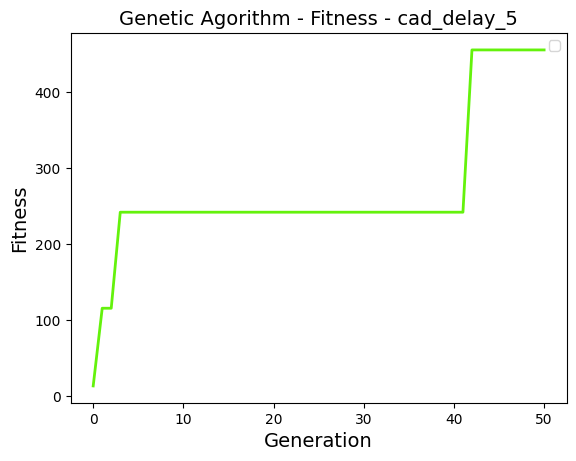

Figure(640x480)
Solution fitness:  455.76804
Solution Predictions:  [[1.1593199]
 [1.1538212]
 [1.1503613]
 ...
 [1.317131 ]
 [1.3229387]
 [1.3190105]]
Solution Absolute Error:  0.04388196
INFO:tensorflow:Assets written to: models/model_cad_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_cad_delay_5_tf/assets


Saved artifact at 'models/model_cad_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cny.
Generation = 1
Fitness    = 14.116388320922852
Generation = 2
Fitness    = 15.743221282958984
Generation = 3
Fitness    = 15.743221282958984
Generation = 4
Fitness    = 15.743221282958984
Generation = 5
Fitness    = 15.743221282958984
Generation = 6
Fitness    = 15.743221282958984
Generation = 7
Fitness    = 15.743221282958984
Generation = 8
Fitness    = 35.59878921508789
Generation = 9
Fitness    = 36.49435043334961
Generation = 10
Fitness    = 36.49435043334961
Generation = 11
Fitness    = 36.49435043334961
Generation = 12
Fitness    = 36.49435043334961
Generation = 13
Fitness    = 36.49435043334961
Generation = 14
Fitness    = 36.49435043334961
Generation = 15
Fitness    = 36.49435043334961
Generation = 16
Fitness    = 36.49435043334961
Generation = 17
Fitness    = 36.49435043334961
Generation = 18
Fitness    = 36.49435043334961
Generation = 19
Fitness    = 36.49435043334961
Generation = 20
Fitness    = 36.49435043334961
Generation = 21
Fitness    

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


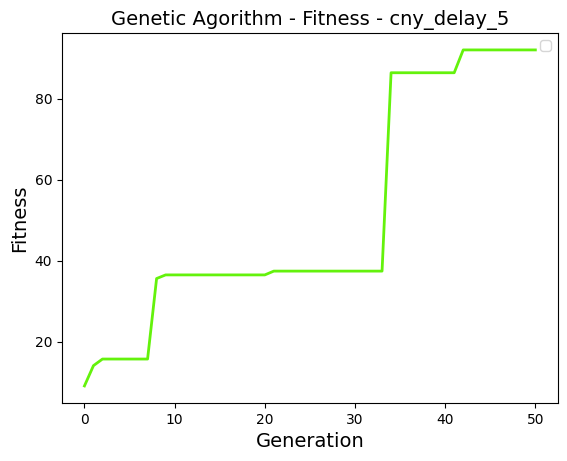

Figure(640x480)
Solution fitness:  91.98565
Solution Predictions:  [[7.3671746]
 [7.3733   ]
 [7.3839793]
 ...
 [7.3989987]
 [7.4242687]
 [7.3905697]]
Solution Absolute Error:  0.2174252
INFO:tensorflow:Assets written to: models/model_cny_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_cny_delay_5_tf/assets


Saved artifact at 'models/model_cny_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: hkd.
Generation = 1
Fitness    = 21.455291748046875
Generation = 2
Fitness    = 21.455291748046875
Generation = 3
Fitness    = 22.130329132080078
Generation = 4
Fitness    = 26.414148330688477
Generation = 5
Fitness    = 26.414148330688477
Generation = 6
Fitness    = 26.414148330688477
Generation = 7
Fitness    = 26.414148330688477
Generation = 8
Fitness    = 26.414148330688477
Generation = 9
Fitness    = 26.414148330688477
Generation = 10
Fitness    = 26.414148330688477
Generation = 11
Fitness    = 115.96043395996094
Generation = 12
Fitness    = 115.96043395996094
Generation = 13
Fitness    = 115.96043395996094
Generation = 14
Fitness    = 115.96043395996094
Generation = 15
Fitness    = 115.96043395996094
Generation = 16
Fitness    = 115.96043395996094
Generation = 17
Fitness    = 115.96043395996094
Generation = 18
Fitness    = 115.96043395996094
Generation = 19
Fitness    = 115.96043395996094
Generation = 20
Fitness    = 115.96043395996094
Generation = 2

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


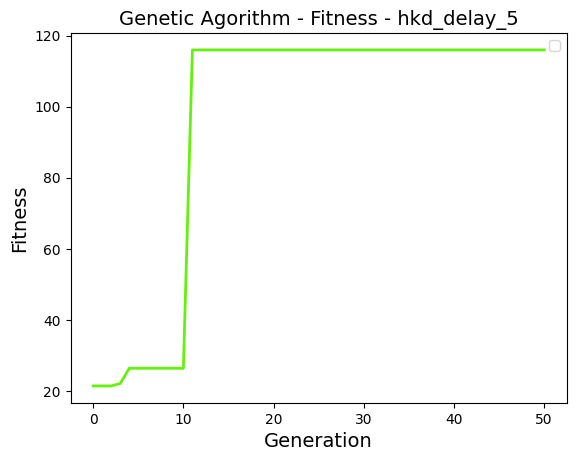

Figure(640x480)
Solution fitness:  115.960434
Solution Predictions:  [[7.934577 ]
 [7.934606 ]
 [7.9325256]
 ...
 [7.9600525]
 [7.9590554]
 [7.9624715]]
Solution Absolute Error:  0.17247261
INFO:tensorflow:Assets written to: models/model_hkd_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_hkd_delay_5_tf/assets


Saved artifact at 'models/model_hkd_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: chf.
Generation = 1
Fitness    = 17.686561584472656
Generation = 2
Fitness    = 29.666763305664062
Generation = 3
Fitness    = 53.941280364990234
Generation = 4
Fitness    = 63.16237258911133
Generation = 5
Fitness    = 63.16237258911133
Generation = 6
Fitness    = 121.56883239746094
Generation = 7
Fitness    = 121.56883239746094
Generation = 8
Fitness    = 121.56883239746094
Generation = 9
Fitness    = 121.56883239746094
Generation = 10
Fitness    = 227.2397918701172
Generation = 11
Fitness    = 227.2397918701172
Generation = 12
Fitness    = 227.2397918701172
Generation = 13
Fitness    = 227.2397918701172
Generation = 14
Fitness    = 227.2397918701172
Generation = 15
Fitness    = 227.2397918701172
Generation = 16
Fitness    = 227.2397918701172
Generation = 17
Fitness    = 227.2397918701172
Generation = 18
Fitness    = 227.2397918701172
Generation = 19
Fitness    = 227.2397918701172
Generation = 20
Fitness    = 227.2397918701172
Generation = 21
Fitness    

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


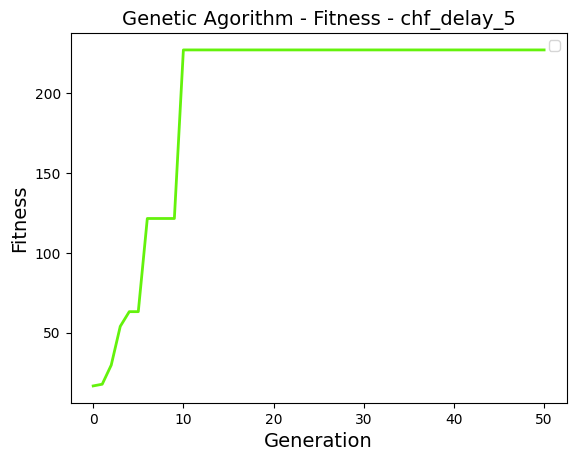

Figure(640x480)
Solution fitness:  227.23979
Solution Predictions:  [[1.5154041 ]
 [1.517374  ]
 [1.5184722 ]
 ...
 [0.9852751 ]
 [0.9829056 ]
 [0.98349464]]
Solution Absolute Error:  0.08801275
INFO:tensorflow:Assets written to: models/model_chf_delay_5_tf/assets


INFO:tensorflow:Assets written to: models/model_chf_delay_5_tf/assets


Saved artifact at 'models/model_chf_delay_5_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ---- ---- ---- ---- ----
Delay: 25 days.
---- ---- ---- ----
Currency: jpy.
Generation = 1
Fitness    = 0.23677857220172882
Generation = 2
Fitness    = 0.27337366342544556
Generation = 3
Fitness    = 0.3198760151863098
Generation = 4
Fitness    = 0.3198760151863098
Generation = 5
Fitness    = 0.4757438004016876
Generation = 6
Fitness    = 0.8498953580856323
Generation = 7
Fitness    = 1.1681476831436157
Generation = 8
Fitness    = 1.5236477851867676
Generation = 9
Fitness    = 1.5236477851867676
Generation = 10
Fitness    = 1.5236477851867676
Generation = 11
Fitness    = 1.5236477851867676
Generation = 12
Fitness    = 1.5236477851867676
Generation = 13
Fitness    = 1.5236477851867676
Generation = 14
Fitness    = 1.5236477851867676
Generation = 15
Fitness    = 1.5236477851867676
Generation = 16
Fitness    = 1.5300439596176147
Generation = 17
Fitness    = 1.5300439596176147
Generation = 18
Fitness    = 1.615617036819458
Generation = 19
Fitness    = 1.615617036819458
Genera

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


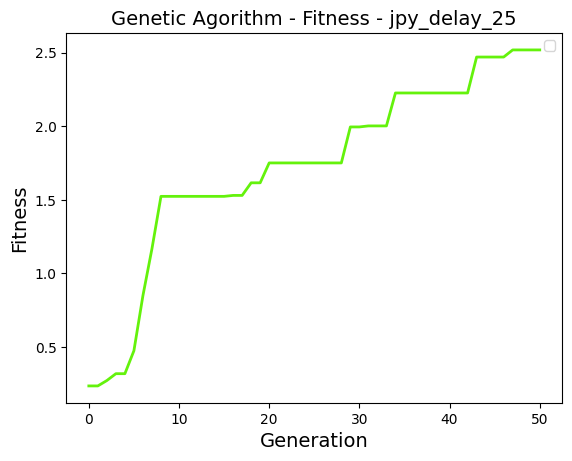

Figure(640x480)
Solution fitness:  2.5177383
Solution Predictions:  [[119.33815 ]
 [119.374886]
 [119.39551 ]
 ...
 [121.2685  ]
 [121.310356]
 [121.333565]]
Solution Absolute Error:  7.9436374
INFO:tensorflow:Assets written to: models/model_jpy_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_jpy_delay_25_tf/assets


Saved artifact at 'models/model_jpy_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: aud.
Generation = 1
Fitness    = 15.094574928283691
Generation = 2
Fitness    = 15.252018928527832
Generation = 3
Fitness    = 48.94350814819336
Generation = 4
Fitness    = 48.94350814819336
Generation = 5
Fitness    = 48.94350814819336
Generation = 6
Fitness    = 48.94350814819336
Generation = 7
Fitness    = 48.94350814819336
Generation = 8
Fitness    = 48.94350814819336
Generation = 9
Fitness    = 48.94350814819336
Generation = 10
Fitness    = 48.94350814819336
Generation = 11
Fitness    = 48.94350814819336
Generation = 12
Fitness    = 48.94350814819336
Generation = 13
Fitness    = 48.94350814819336
Generation = 14
Fitness    = 48.94350814819336
Generation = 15
Fitness    = 96.7530746459961
Generation = 16
Fitness    = 96.7530746459961
Generation = 17
Fitness    = 96.7530746459961
Generation = 18
Fitness    = 96.7530746459961
Generation = 19
Fitness    = 96.7530746459961
Generation = 20
Fitness    = 96.7530746459961
Generation = 21
Fitness    = 96.753074

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


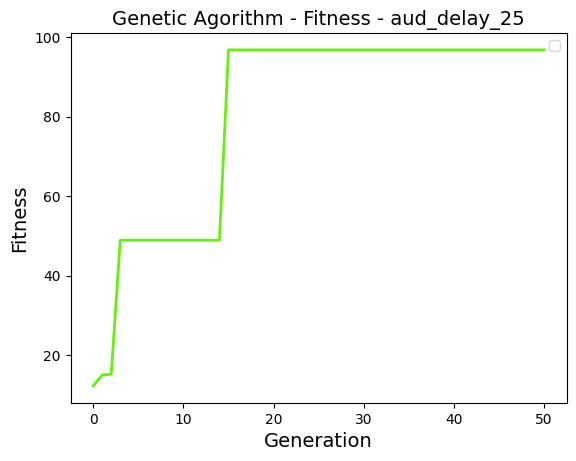

Figure(640x480)
Solution fitness:  96.753075
Solution Predictions:  [[1.1570461]
 [1.159065 ]
 [1.1585686]
 ...
 [1.7546064]
 [1.7197804]
 [1.62463  ]]
Solution Absolute Error:  0.20671177
INFO:tensorflow:Assets written to: models/model_aud_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_aud_delay_25_tf/assets


Saved artifact at 'models/model_aud_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cad.
Generation = 1
Fitness    = 19.771610260009766
Generation = 2
Fitness    = 19.771610260009766
Generation = 3
Fitness    = 19.9980525970459
Generation = 4
Fitness    = 45.16416931152344
Generation = 5
Fitness    = 113.81361389160156
Generation = 6
Fitness    = 113.81361389160156
Generation = 7
Fitness    = 113.81361389160156
Generation = 8
Fitness    = 113.81361389160156
Generation = 9
Fitness    = 113.81361389160156
Generation = 10
Fitness    = 113.81361389160156
Generation = 11
Fitness    = 113.81361389160156
Generation = 12
Fitness    = 113.81361389160156
Generation = 13
Fitness    = 113.81361389160156
Generation = 14
Fitness    = 113.81361389160156
Generation = 15
Fitness    = 113.81361389160156
Generation = 16
Fitness    = 113.81361389160156
Generation = 17
Fitness    = 113.81361389160156
Generation = 18
Fitness    = 113.81361389160156
Generation = 19
Fitness    = 113.81361389160156
Generation = 20
Fitness    = 113.81361389160156
Generation = 21
F

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


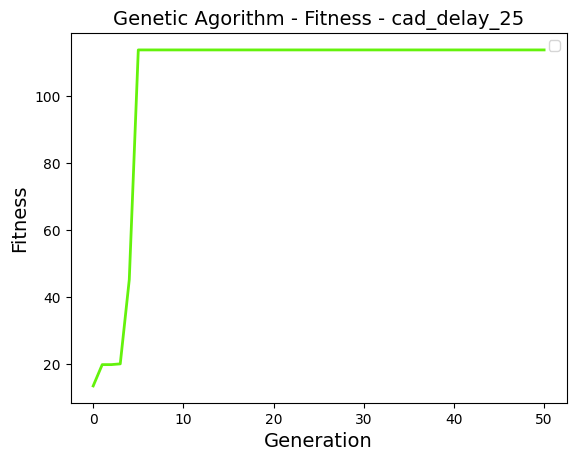

Figure(640x480)
Solution fitness:  113.813614
Solution Predictions:  [[1.3542473]
 [1.3528479]
 [1.3542317]
 ...
 [1.4471452]
 [1.4478636]
 [1.4471463]]
Solution Absolute Error:  0.17572589
INFO:tensorflow:Assets written to: models/model_cad_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_cad_delay_25_tf/assets


Saved artifact at 'models/model_cad_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cny.
Generation = 1
Fitness    = 24.957111358642578
Generation = 2
Fitness    = 24.957111358642578
Generation = 3
Fitness    = 24.957111358642578
Generation = 4
Fitness    = 24.957111358642578
Generation = 5
Fitness    = 37.93452453613281
Generation = 6
Fitness    = 37.93452453613281
Generation = 7
Fitness    = 37.93452453613281
Generation = 8
Fitness    = 46.36951446533203
Generation = 9
Fitness    = 46.36951446533203
Generation = 10
Fitness    = 46.36951446533203
Generation = 11
Fitness    = 46.36951446533203
Generation = 12
Fitness    = 46.36951446533203
Generation = 13
Fitness    = 46.36951446533203
Generation = 14
Fitness    = 46.36951446533203
Generation = 15
Fitness    = 46.36951446533203
Generation = 16
Fitness    = 46.36951446533203
Generation = 17
Fitness    = 46.36951446533203
Generation = 18
Fitness    = 46.36951446533203
Generation = 19
Fitness    = 46.36951446533203
Generation = 20
Fitness    = 46.36951446533203
Generation = 21
Fitness    = 4

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


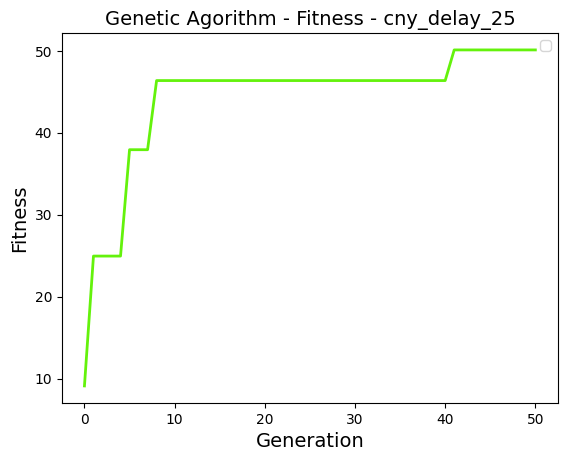

Figure(640x480)
Solution fitness:  50.10873
Solution Predictions:  [[4.982738 ]
 [4.988048 ]
 [4.9678645]
 ...
 [6.4650702]
 [6.465611 ]
 [6.435659 ]]
Solution Absolute Error:  0.39913204
INFO:tensorflow:Assets written to: models/model_cny_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_cny_delay_25_tf/assets


Saved artifact at 'models/model_cny_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: hkd.
Generation = 1
Fitness    = 32.16017150878906
Generation = 2
Fitness    = 32.16017150878906
Generation = 3
Fitness    = 366.34149169921875
Generation = 4
Fitness    = 366.34149169921875
Generation = 5
Fitness    = 366.34149169921875
Generation = 6
Fitness    = 366.34149169921875
Generation = 7
Fitness    = 366.34149169921875
Generation = 8
Fitness    = 366.34149169921875
Generation = 9
Fitness    = 366.34149169921875
Generation = 10
Fitness    = 366.34149169921875
Generation = 11
Fitness    = 366.34149169921875
Generation = 12
Fitness    = 366.34149169921875
Generation = 13
Fitness    = 366.34149169921875
Generation = 14
Fitness    = 366.34149169921875
Generation = 15
Fitness    = 366.34149169921875
Generation = 16
Fitness    = 366.34149169921875
Generation = 17
Fitness    = 366.34149169921875
Generation = 18
Fitness    = 366.34149169921875
Generation = 19
Fitness    = 366.34149169921875
Generation = 20
Fitness    = 366.34149169921875
Generation = 21


/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


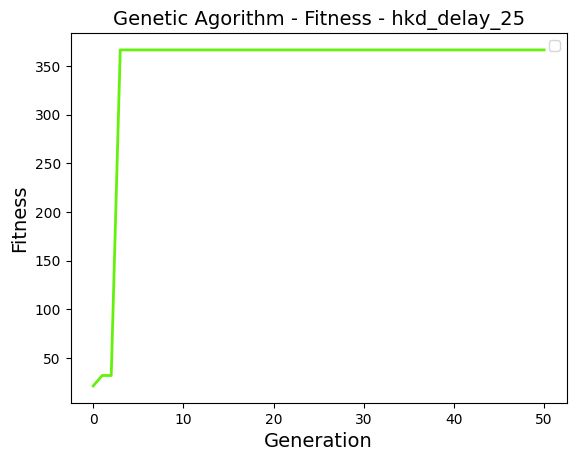

Figure(640x480)
Solution fitness:  366.3415
Solution Predictions:  [[7.850654 ]
 [7.850864 ]
 [7.854608 ]
 ...
 [7.838672 ]
 [7.8384833]
 [7.8369594]]
Solution Absolute Error:  0.054593857
INFO:tensorflow:Assets written to: models/model_hkd_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_hkd_delay_25_tf/assets


Saved artifact at 'models/model_hkd_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: chf.
Generation = 1
Fitness    = 16.628414154052734
Generation = 2
Fitness    = 39.972251892089844
Generation = 3
Fitness    = 39.972251892089844
Generation = 4
Fitness    = 115.32637023925781
Generation = 5
Fitness    = 223.661376953125
Generation = 6
Fitness    = 223.661376953125
Generation = 7
Fitness    = 223.661376953125
Generation = 8
Fitness    = 223.661376953125
Generation = 9
Fitness    = 223.661376953125
Generation = 10
Fitness    = 223.661376953125
Generation = 11
Fitness    = 223.661376953125
Generation = 12
Fitness    = 223.661376953125
Generation = 13
Fitness    = 223.661376953125
Generation = 14
Fitness    = 223.661376953125
Generation = 15
Fitness    = 223.661376953125
Generation = 16
Fitness    = 223.661376953125
Generation = 17
Fitness    = 223.661376953125
Generation = 18
Fitness    = 223.661376953125
Generation = 19
Fitness    = 223.661376953125
Generation = 20
Fitness    = 223.661376953125
Generation = 21
Fitness    = 223.661376953125


/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


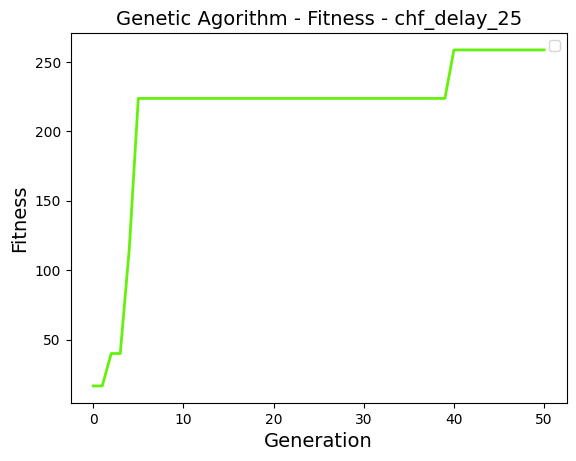

Figure(640x480)
Solution fitness:  258.58292
Solution Predictions:  [[0.9575989 ]
 [0.95732737]
 [0.9571631 ]
 ...
 [0.8796799 ]
 [0.87789965]
 [0.87522745]]
Solution Absolute Error:  0.07734462
INFO:tensorflow:Assets written to: models/model_chf_delay_25_tf/assets


INFO:tensorflow:Assets written to: models/model_chf_delay_25_tf/assets


Saved artifact at 'models/model_chf_delay_25_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ---- ---- ---- ---- ----
Delay: 45 days.
---- ---- ---- ----
Currency: jpy.
Generation = 1
Fitness    = 0.2368752360343933
Generation = 2
Fitness    = 0.2368752360343933
Generation = 3
Fitness    = 0.2462950199842453
Generation = 4
Fitness    = 0.26260459423065186
Generation = 5
Fitness    = 0.28752923011779785
Generation = 6
Fitness    = 0.28752923011779785
Generation = 7
Fitness    = 0.3600640892982483
Generation = 8
Fitness    = 0.48439574241638184
Generation = 9
Fitness    = 0.7097482085227966
Generation = 10
Fitness    = 0.7611636519432068
Generation = 11
Fitness    = 1.0676761865615845
Generation = 12
Fitness    = 1.4402433633804321
Generation = 13
Fitness    = 1.4602128267288208
Generation = 14
Fitness    = 1.4602128267288208
Generation = 15
Fitness    = 1.535134196281433
Generation = 16
Fitness    = 1.535134196281433
Generation = 17
Fitness    = 1.535134196281433
Generation = 18
Fitness    = 1.535134196281433
Generation = 19
Fitness    = 1.7049044370651245
Genera

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


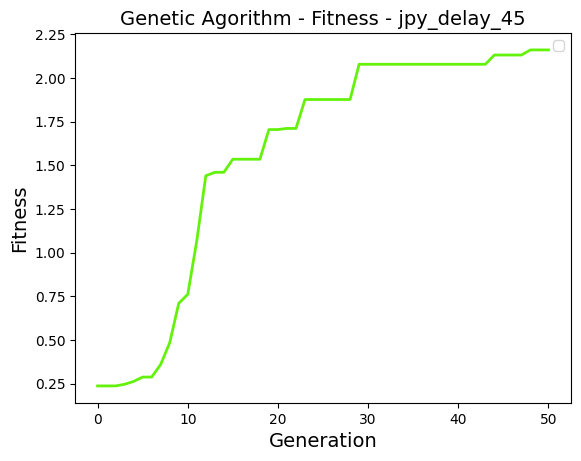

Figure(640x480)
Solution fitness:  2.1610155
Solution Predictions:  [[116.66627 ]
 [116.69558 ]
 [116.72362 ]
 ...
 [126.57932 ]
 [126.58541 ]
 [126.623436]]
Solution Absolute Error:  9.254909
INFO:tensorflow:Assets written to: models/model_jpy_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_jpy_delay_45_tf/assets


Saved artifact at 'models/model_jpy_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: aud.
Generation = 1
Fitness    = 16.841630935668945
Generation = 2
Fitness    = 271.23046875
Generation = 3
Fitness    = 271.23046875
Generation = 4
Fitness    = 271.23046875
Generation = 5
Fitness    = 271.23046875
Generation = 6
Fitness    = 271.23046875
Generation = 7
Fitness    = 271.23046875
Generation = 8
Fitness    = 271.23046875
Generation = 9
Fitness    = 271.23046875
Generation = 10
Fitness    = 271.23046875
Generation = 11
Fitness    = 271.23046875
Generation = 12
Fitness    = 271.23046875
Generation = 13
Fitness    = 271.23046875
Generation = 14
Fitness    = 271.23046875
Generation = 15
Fitness    = 271.23046875
Generation = 16
Fitness    = 271.23046875
Generation = 17
Fitness    = 271.23046875
Generation = 18
Fitness    = 271.23046875
Generation = 19
Fitness    = 271.23046875
Generation = 20
Fitness    = 271.23046875
Generation = 21
Fitness    = 271.23046875
Generation = 22
Fitness    = 271.23046875
Generation = 23
Fitness    = 271.23046875
Ge

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


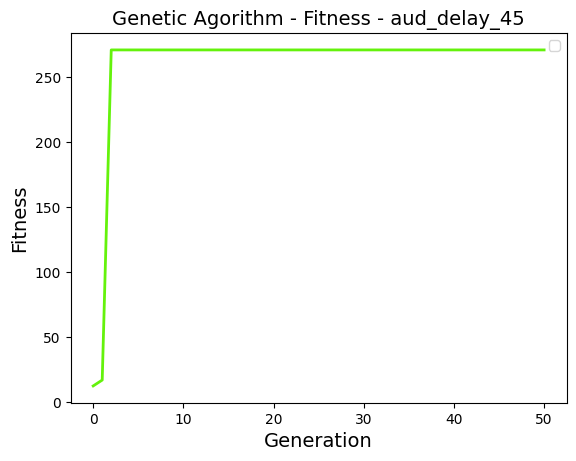

Figure(640x480)
Solution fitness:  271.23047
Solution Predictions:  [[1.1654607]
 [1.1847471]
 [1.199891 ]
 ...
 [1.7157668]
 [1.7082525]
 [1.7041329]]
Solution Absolute Error:  0.07373802
INFO:tensorflow:Assets written to: models/model_aud_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_aud_delay_45_tf/assets


Saved artifact at 'models/model_aud_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cad.
Generation = 1
Fitness    = 16.914764404296875
Generation = 2
Fitness    = 41.27055358886719
Generation = 3
Fitness    = 47.22842788696289
Generation = 4
Fitness    = 55.39301300048828
Generation = 5
Fitness    = 93.35955810546875
Generation = 6
Fitness    = 93.35955810546875
Generation = 7
Fitness    = 93.35955810546875
Generation = 8
Fitness    = 93.35955810546875
Generation = 9
Fitness    = 93.35955810546875
Generation = 10
Fitness    = 93.35955810546875
Generation = 11
Fitness    = 93.35955810546875
Generation = 12
Fitness    = 93.35955810546875
Generation = 13
Fitness    = 93.35955810546875
Generation = 14
Fitness    = 93.35955810546875
Generation = 15
Fitness    = 93.35955810546875
Generation = 16
Fitness    = 93.35955810546875
Generation = 17
Fitness    = 93.35955810546875
Generation = 18
Fitness    = 93.35955810546875
Generation = 19
Fitness    = 93.35955810546875
Generation = 20
Fitness    = 93.35955810546875
Generation = 21
Fitness    = 93.3

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


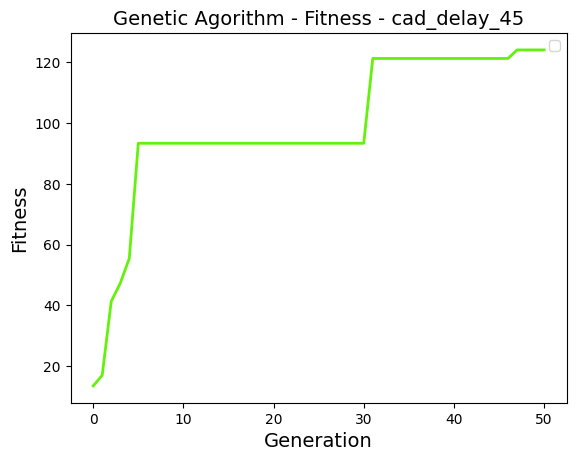

Figure(640x480)
Solution fitness:  124.12009
Solution Predictions:  [[1.3249288]
 [1.3191134]
 [1.3227539]
 ...
 [1.6651523]
 [1.654183 ]
 [1.6498365]]
Solution Absolute Error:  0.16113426
INFO:tensorflow:Assets written to: models/model_cad_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_cad_delay_45_tf/assets


Saved artifact at 'models/model_cad_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: cny.
Generation = 1
Fitness    = 34.27644348144531
Generation = 2
Fitness    = 34.27644348144531
Generation = 3
Fitness    = 34.27644348144531
Generation = 4
Fitness    = 34.27644348144531
Generation = 5
Fitness    = 34.27644348144531
Generation = 6
Fitness    = 34.27644348144531
Generation = 7
Fitness    = 35.17938995361328
Generation = 8
Fitness    = 35.17938995361328
Generation = 9
Fitness    = 35.17938995361328
Generation = 10
Fitness    = 35.17938995361328
Generation = 11
Fitness    = 35.17938995361328
Generation = 12
Fitness    = 35.17938995361328
Generation = 13
Fitness    = 35.17938995361328
Generation = 14
Fitness    = 35.17938995361328
Generation = 15
Fitness    = 35.17938995361328
Generation = 16
Fitness    = 35.17938995361328
Generation = 17
Fitness    = 63.12487030029297
Generation = 18
Fitness    = 63.12487030029297
Generation = 19
Fitness    = 63.12487030029297
Generation = 20
Fitness    = 63.12487030029297
Generation = 21
Fitness    = 63.12

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


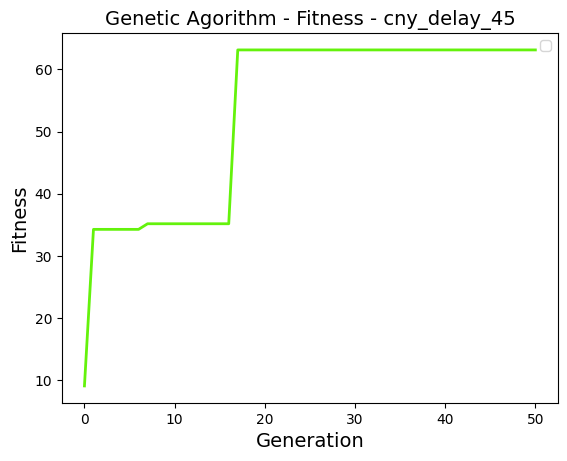

Figure(640x480)
Solution fitness:  63.12487
Solution Predictions:  [[7.189682 ]
 [7.1664224]
 [7.175743 ]
 ...
 [7.595811 ]
 [7.601159 ]
 [7.61649  ]]
Solution Absolute Error:  0.31683233
INFO:tensorflow:Assets written to: models/model_cny_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_cny_delay_45_tf/assets


Saved artifact at 'models/model_cny_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: hkd.
Generation = 1
Fitness    = 22.553241729736328
Generation = 2
Fitness    = 22.553241729736328
Generation = 3
Fitness    = 22.553241729736328
Generation = 4
Fitness    = 936.1930541992188
Generation = 5
Fitness    = 936.1930541992188
Generation = 6
Fitness    = 936.1930541992188
Generation = 7
Fitness    = 936.1930541992188
Generation = 8
Fitness    = 936.1930541992188
Generation = 9
Fitness    = 936.1930541992188
Generation = 10
Fitness    = 936.1930541992188
Generation = 11
Fitness    = 936.1930541992188
Generation = 12
Fitness    = 936.1930541992188
Generation = 13
Fitness    = 936.1930541992188
Generation = 14
Fitness    = 936.1930541992188
Generation = 15
Fitness    = 936.1930541992188
Generation = 16
Fitness    = 936.1930541992188
Generation = 17
Fitness    = 936.1930541992188
Generation = 18
Fitness    = 936.1930541992188
Generation = 19
Fitness    = 936.1930541992188
Generation = 20
Fitness    = 936.1930541992188
Generation = 21
Fitness    = 93

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


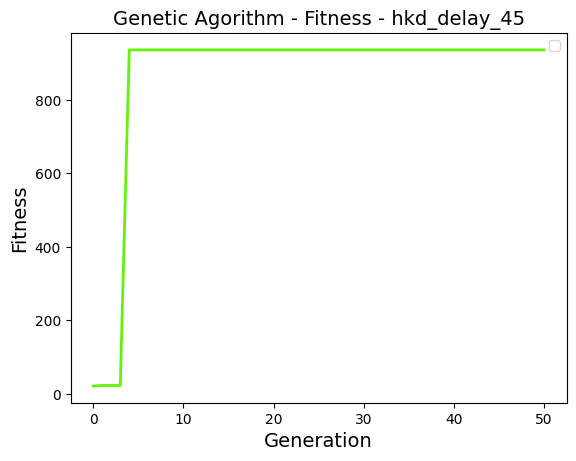

Figure(640x480)
Solution fitness:  936.19305
Solution Predictions:  [[7.7788   ]
 [7.78174  ]
 [7.778691 ]
 ...
 [7.8127537]
 [7.806837 ]
 [7.8120666]]
Solution Absolute Error:  0.021363106
INFO:tensorflow:Assets written to: models/model_hkd_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_hkd_delay_45_tf/assets


Saved artifact at 'models/model_hkd_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
                           PyGAD Lifecycle                           
INFO:pygad.pygad:                           PyGAD Lifecycle                           
INFO:pygad.pygad:======================================================================
Step                  Handler                          Output Shape  
INFO:pygad.pygad:Step                  Handler                          Output Shape  
INFO:pygad.pygad:======================================================================
Fitness Function      fitness_function()               (1)           
INFO:pygad.pygad:Fitness Function      fitness_function()               (1)           
----------------------------------------------------------------------
INFO:pygad.pygad:----------------------------------------------------------------------
Parent Selection      steady_state_

---- ---- ---- ----
Currency: chf.
Generation = 1
Fitness    = 18.22075843811035
Generation = 2
Fitness    = 19.26192283630371
Generation = 3
Fitness    = 50.728424072265625
Generation = 4
Fitness    = 50.728424072265625
Generation = 5
Fitness    = 50.728424072265625
Generation = 6
Fitness    = 50.728424072265625
Generation = 7
Fitness    = 50.728424072265625
Generation = 8
Fitness    = 50.728424072265625
Generation = 9
Fitness    = 50.728424072265625
Generation = 10
Fitness    = 50.728424072265625
Generation = 11
Fitness    = 50.728424072265625
Generation = 12
Fitness    = 50.728424072265625
Generation = 13
Fitness    = 50.728424072265625
Generation = 14
Fitness    = 53.874019622802734
Generation = 15
Fitness    = 53.874019622802734
Generation = 16
Fitness    = 53.874019622802734
Generation = 17
Fitness    = 53.874019622802734
Generation = 18
Fitness    = 53.874019622802734
Generation = 19
Fitness    = 113.28447723388672
Generation = 20
Fitness    = 113.28447723388672
Generation = 21


/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


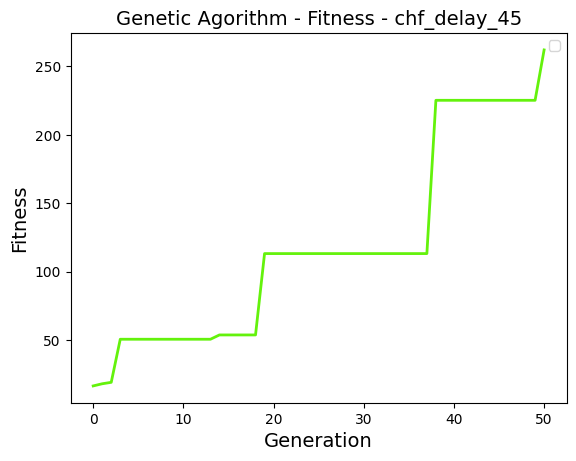

Figure(640x480)
Solution fitness:  262.014
Solution Predictions:  [[0.9214282 ]
 [0.9250093 ]
 [0.927732  ]
 ...
 [1.0048935 ]
 [0.99995255]
 [1.0043492 ]]
Solution Absolute Error:  0.07633179
INFO:tensorflow:Assets written to: models/model_chf_delay_45_tf/assets


INFO:tensorflow:Assets written to: models/model_chf_delay_45_tf/assets


Saved artifact at 'models/model_chf_delay_45_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5985612240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985612624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985611856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985613968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985615312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5985614352: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [8]:
import pygad.kerasga

# - Instance of the pygad.kerasga.KerasGA class
keras_ga = pygad.kerasga.KerasGA(model=lstm_model, num_solutions=10)

# Genetic Algorithm
for index, delay in enumerate(delays):
    real_delay = 0
    if index == 0:
        real_delay = 5
    if index == 1:
        real_delay = 25
    if index == 2:
        real_delay = 45
    print(f"---- ---- ---- ---- ---- ---- ---- ----\nDelay: {real_delay} days.")
    for currency in currencies:
        print(f"---- ---- ---- ----\nCurrency: {currency}.")

        # - Fitness function
        def fitness_function(ga_instance, solution, solution_index):
            global keras_ga, lstm_model
            predictions = pygad.kerasga.predict(model=lstm_model, solution=solution, data=data_inputs_all[f"{currency}_delay_{real_delay}"])
            mae = keras.losses.MeanAbsoluteError()
            absolute_error = mae(data_outputs_all[f"{currency}_delay_{real_delay}"], predictions).numpy() + 0.00000001
            solution_fitness = 20 / absolute_error
            return solution_fitness

        # - Track GA
        def on_generation(ga_instance):
            print(f"Generation = {ga_instance.generations_completed}")
            print(f"Fitness    = {ga_instance.best_solution()[1]}")

        # - Create instance of the pygad.GA class
        num_generations = 50 # reduced from 400 to 50 as there was already the tuner stage selecting the best model structure, and in order to reduce time as many models need to be created
        num_parents_mating = 4
        initial_population = keras_ga.population_weights

        ga_instance = pygad.GA(
                                num_generations=num_generations,
                                num_parents_mating=num_parents_mating,
                                initial_population=initial_population,
                                fitness_func=fitness_function,
                                on_generation=on_generation,
                                suppress_warnings=True,
                                parallel_processing=["thread", 4],
                                mutation_type="adaptive",
                                mutation_percent_genes=[8,4]
                            )

        # - Run
        ga_instance.summary()

        ga_instance.run()

        print(ga_instance.plot_fitness(title=f"Genetic Agorithm - Fitness - {currency}_delay_{real_delay}", linewidth=2))

        # - Run best solution
        solution, solution_fitness, solution_index = ga_instance.best_solution()
        predictions = pygad.kerasga.predict(model=lstm_model, solution=solution,data=data_inputs_all[f"{currency}_delay_{real_delay}"])
        mae = keras.losses.MeanAbsoluteError()
        absolute_error = mae(data_outputs_all[f"{currency}_delay_{real_delay}"], predictions).numpy()
        print("Solution fitness: ", solution_fitness)
        print("Solution Predictions: ", predictions)
        print("Solution Absolute Error: ", absolute_error)

        # - Save Genetic Algorithm
        ga_instance.save(filename=f"genetic-algorithms/genetic_algorithm_{currency}_delay_{real_delay}")

        # ---- ---- Export model (keras and tensorflow) ---- ----
        # Get the best solution as a keras weight matrix
        ga_best_solution_weights = pygad.kerasga.model_weights_as_matrix(model=lstm_model, weights_vector=solution)

        # Set the weights
        lstm_model.set_weights(ga_best_solution_weights)

        # Save the model (for Keras)
        lstm_model.save(f"models/model_{currency}_delay_{real_delay}.keras")

        # Save the model (for Tensorflow)
        lstm_model.export(f"models/model_{currency}_delay_{real_delay}_tf", format="tf_saved_model")

        # ---- ---- ---- ----

## About the code

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries, Preparing the data. Retrieved from https://learning.oreilly.com/library/view/deep-learning-with/9781617296864/Text/10.htm#heading_id_5

2- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries, Let’s try a basic machine learning model. Retrieved from https://learning.oreilly.com/library/view/deep-learning-with/9781617296864/Text/10.htm#heading_id_7

3- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries, Let’s try a 1D convolutional model. Retrieved from https://learning.oreilly.com/library/view/deep-learning-with/9781617296864/Text/10.htm#heading_id_8

4- Keras. Getting started with KerasTuner. Retrieved from https://keras.io/keras_tuner/getting_started/

5- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#